# Lecture 18 (Multi-dimensional data)

## Exercise 18.1 (numpy)

1.  Generate two 5x5 matrices with entries drawn from a standard _normal distribution_ (mean 0, variance 1). `numpy.random.normal` might come in handy here. Find the inverse of the matrices. Check by matrix multiplication, that it is in fact the inverses you have found.


2.  Find the mean of each row and each column of the matrices without using loops. `numpy.mean` might come in handy here.


3.  Create a 100x100 matrix with entries drawn from the _uniform distribution_ between 0 and 1. Find all rows where the sum exceeds 55. Find both the row index and the sum. (Try to have a look at the functions `numpy.sum` and `numpy.where`).

In [ ]:
import numpy as np 

L = np.random.normal(size=(5,5))

L_I = np.linalg.inv(L)

I1 = np.round(L @ L_I)
I2 = np.round(L.T * L_I)

print(I1)
print(I2)

row = np.mean(L, axis=1)
col = np.mean(L, axis=0)

print(f"{col}\n{row}\n")

M = np.random.uniform(size=(100,100))
idx = np.where(M.sum(axis=1) > 55)

for i in list(*idx):
    print(f"{i}: {M[i, :].sum()}")

[[ 1. -0. -0.  0. -0.]
 [ 0.  1.  0.  0. -0.]
 [-0. -0.  1. -0. -0.]
 [ 0.  0. -0.  1. -0.]
 [-0.  0.  0.  0.  1.]]
[[ 0.  0.  1. -0. -0.]
 [ 1.  0. -0.  0. -0.]
 [ 0.  1.  0.  0. -0.]
 [-0.  0. -0.  0.  1.]
 [ 0. -0.  0.  1. -0.]]
[-0.0535621  -0.1100425  -0.52736268 -0.05059969 -0.35348664]
[-0.62314812 -0.12327837 -0.63249884 -0.51137211  0.79524384]

[ 1 42 91]
1: 56.47928161180482
42: 57.92842415616701
91: 56.90742070899952


In [86]:
M = np.random.normal(size=(3,2))
print(M)
print(M.shape)

[[ 0.90744438  1.22310608]
 [-0.63974856 -0.38560363]
 [ 0.98400445  2.10345741]]
(3, 2)


## Exercise 18.2 (computing pi using sampling)

![Circle sampling](images/circle_sample.png)

In this exercise we want compute an approximation of π using random sampling: Given a uniformly selected random point in the unit-square [0,1]<sup>2</sup>, it has probability π / 4 to have distance ≤ 1.0 to (0,0), i.e. to be within the circle with radius one and center located in the origo.

1.  Compute an approximation of π from sufficiently many uniform samples from the unit-square [0,1]<sup>2</sup>. You solution must use `numpy`. You can e.g. generate a 2 x 1000000 matrix with random values and use some of the functions `numpy.random.random`,`numpy.random.uniform`, `numpy.linalg.norm`, `numpy.average`, `numpy.sum`, `numpy.size`, ...


2.  Use `numpy` and `matplotlib` to plot a figure of your sample, like in the figure.  Try to use `numpy` masking ([Boolean array indexing](https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing)) to select the different colors.

[False False  True ...  True  True  True]


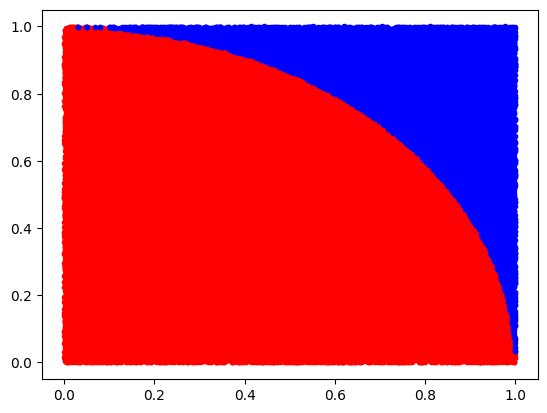

3.1394


In [96]:
import numpy as np 
import matplotlib.pyplot as plt

points = np.random.uniform(size=(2, 100000))

mask = np.linalg.norm(points, axis=0) <= 1
print(mask)

plt.plot(*points[:, mask], "r.")
plt.plot(*points[:, ~mask], "b.")

plt.show()

print(4*np.average(mask))

## Exercise 18.3 (polynomial fit)

Consider the below list `L` of 2D points. Apply `numpy.polyfit` for different degrees of the polynomial fitting, and find the minimum degree polynomial where the maximal vertical distance between a point `(x, y)` in `L` and the polynomial `poly` is at most `1`, i.e. `abs(y - poly(x)) <= 1` for all `(x, y)` in `L`.  Plot the data points and the different polynomial approximations. Present your work in Jupyter.

    L = [(2, 3), (5, 7), (4, 10), (10, 15), (2.5, 5), (8, 4), (9, 10), (6, 6)]

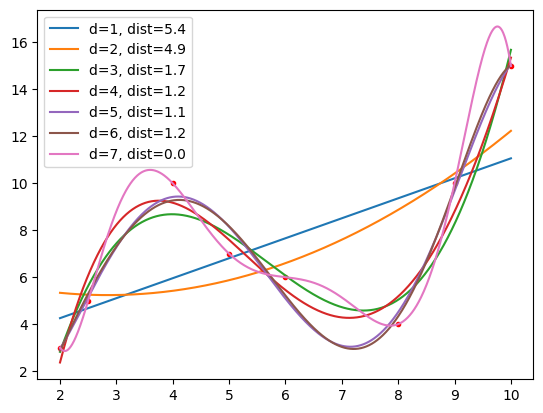

In [72]:
import numpy as np 
import matplotlib.pyplot as plt

L = [(2, 3), (5, 7), (4, 10), (10, 15), (2.5, 5), (8, 4), (9, 10), (6, 6)]
x, y = zip(*L)

plt.plot(x, y, "r.")
d = 0

while True:
    d += 1
    coeff = np.polyfit(x, y, d)

    fx = np.linspace(min(x), max(x), 1000)
    fy = np.polyval(coeff, fx)

    dist = np.max(np.abs(y - np.polyval(coeff, x)))

    plt.plot(fx, fy, "-", label=f"d={d}, dist={dist:.1f}")

    if dist < 1:
        break

plt.legend()
plt.show()
